# Term Deposit Subscription Prediction (Bank Marketing)

## Problem Statement
A Portuguese bank ran phone-based marketing campaigns to sell term deposits.
Not every customer contacted ends up subscribing, and calling everyone is
costly. This notebook builds a classifier that predicts whether a customer
will subscribe (y = yes) based on their profile, campaign contact history,
and macroeconomic context — and explains individual predictions with SHAP.

## Objective
1. Explore and clean the Bank Marketing dataset
2. Encode categorical features properly
3. Train and compare Logistic Regression and Random Forest classifiers
4. Evaluate with Confusion Matrix, F1-Score, and ROC Curve
5. Use SHAP to explain at least 5 individual predictions

## 1. Dataset Description & Loading

**Source:** UCI Machine Learning Repository – Bank Marketing Dataset
**File:** bank-additional-full.csv — 41,188 rows, 20 input features, 1 target (y)

| Group | Features |
|---|---|
| Client info | age, job, marital, education, default, housing, loan |
| Campaign contact | contact, month, day_of_week, duration, campaign |
| Previous campaign | pdays, previous, poutcome |
| Economic context | emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed |
| Target | y (yes/no) |

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, f1_score,
                              roc_curve, roc_auc_score)
import shap

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

url = 'https://raw.githubusercontent.com/llhthinker/MachineLearningLab/master/UCI%20Bank%20Marketing%20Data%20Set/data/bank-additional/bank-additional-full.csv'
df = pd.read_csv(url, sep=';')
print("Shape:", df.shape)
df.head()

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

## 2. Exploratory Data Analysis (EDA)

y
no     36548
yes     4640
Name: count, dtype: int64
y
no     0.887
yes    0.113
Name: proportion, dtype: float64


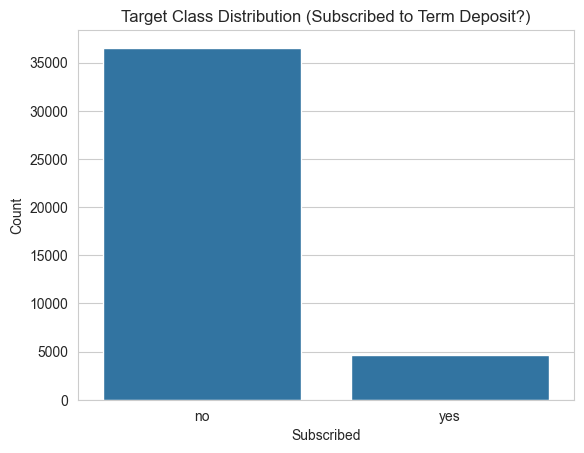

In [5]:
print(df['y'].value_counts())
print(df['y'].value_counts(normalize=True).round(3))

sns.countplot(x='y', data=df)
plt.title('Target Class Distribution (Subscribed to Term Deposit?)')
plt.xlabel('Subscribed')
plt.ylabel('Count')
plt.show()

The target is **imbalanced**: only ~11.3% of customers subscribed. This means
accuracy alone would be misleading — a model predicting "no" for everyone
would already be ~89% accurate. We prioritize **F1-score** and **ROC-AUC**
instead, and use class_weight='balanced' during training.

In [6]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
unknown_counts = {c: (df[c] == 'unknown').sum() for c in cat_cols if (df[c] == 'unknown').sum() > 0}
unknown_counts

C:\Users\FIREFLY LAPTOP'S\AppData\Local\Temp\ipykernel_10304\3756899753.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


{'job': np.int64(330),
 'marital': np.int64(80),
 'education': np.int64(1731),
 'default': np.int64(8597),
 'housing': np.int64(990),
 'loan': np.int64(990)}

Several categorical columns use the literal string "unknown" instead of a
true missing value. Rather than dropping these rows, we keep "unknown" as
its own category — it may itself carry predictive signal.

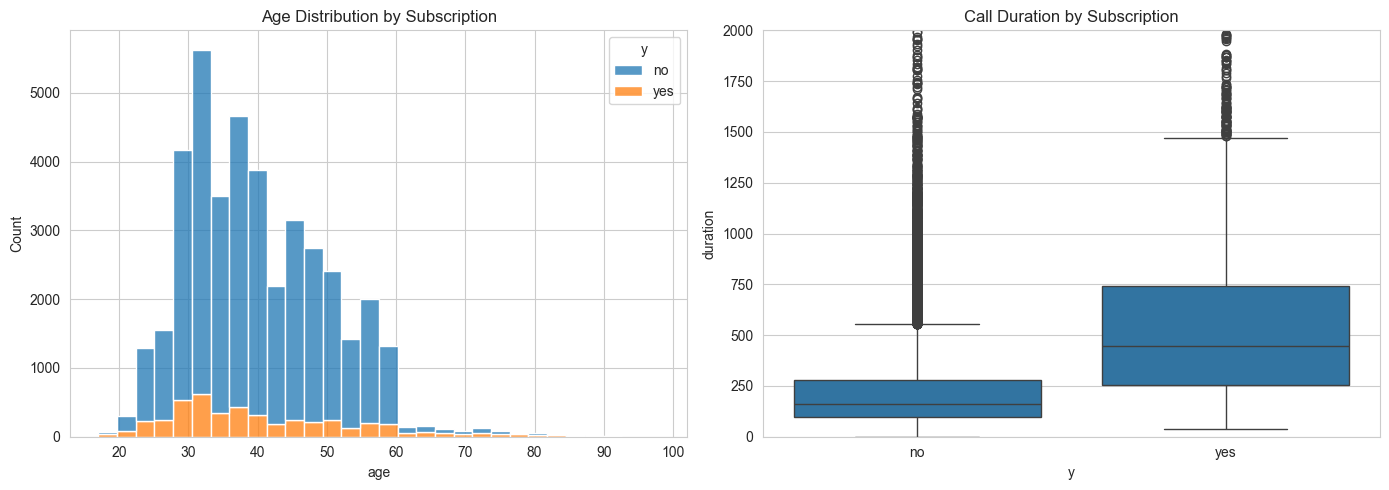

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='age', hue='y', multiple='stack', bins=30, ax=axes[0])
axes[0].set_title('Age Distribution by Subscription')

sns.boxplot(data=df, x='y', y='duration', ax=axes[1])
axes[1].set_title('Call Duration by Subscription')
axes[1].set_ylim(0, 2000)

plt.tight_layout()
plt.show()

duration (last call length in seconds) is strongly associated with
subscribing — longer calls tend to end in a "yes". However, **duration is
only known after the call ends**, so a model using it cannot be used to
decide *who to call* ahead of time — only to explain outcomes after the
fact. We keep it here (as instructed by the task) but flag this
data-leakage caveat clearly.

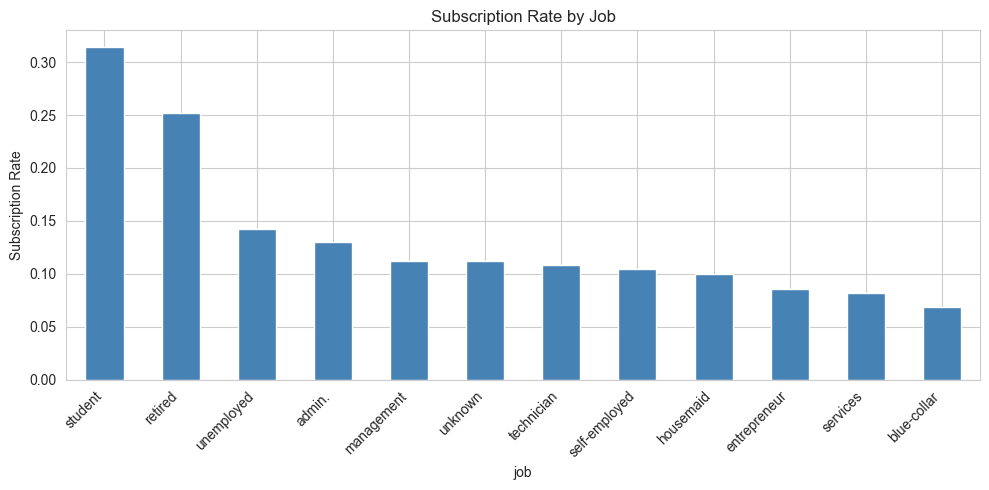

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
subscribe_rate = df.groupby('job')['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)
subscribe_rate.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Subscription Rate by Job')
ax.set_ylabel('Subscription Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

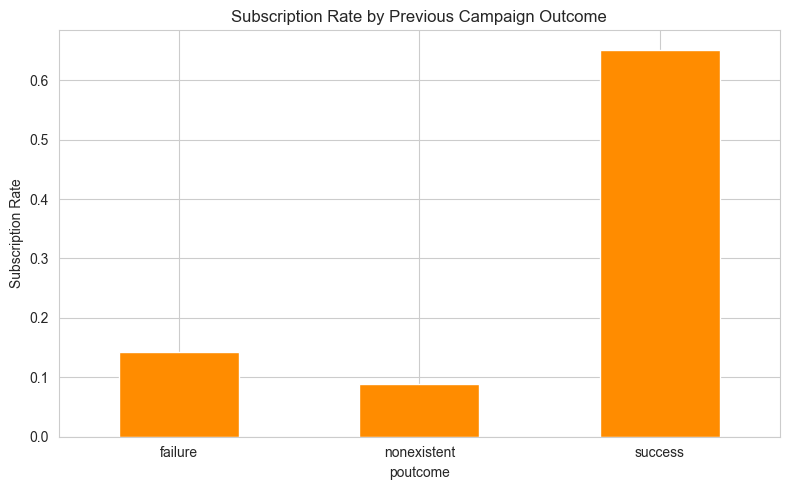

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
poutcome_rate = df.groupby('poutcome')['y'].apply(lambda x: (x == 'yes').mean())
poutcome_rate.plot(kind='bar', ax=ax, color='darkorange')
ax.set_title('Subscription Rate by Previous Campaign Outcome')
ax.set_ylabel('Subscription Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Customers with a **previously successful** campaign outcome (poutcome =
success) subscribe at a far higher rate than others — a strong, intuitive
signal that we'll confirm later with SHAP.

## 3. Data Cleaning & Preprocessing

Steps:
1. Encode target y as 0/1
2. Ordinal-encode education (it has a natural order)
3. One-Hot Encode remaining nominal categorical columns
4. Train/test split (stratified, 80/20)
5. Scale numeric features for Logistic Regression

In [10]:
data = df.copy()
data['y'] = data['y'].map({'yes': 1, 'no': 0})

education_order = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y', 'high.school',
                    'professional.course', 'university.degree', 'unknown']
data['education'] = pd.Categorical(data['education'], categories=education_order, ordered=True).codes

# IMPORTANT: exclude 'y' from columns you one-hot encode
nominal_cols = [c for c in cat_cols if c not in ('education', 'y')]
data_encoded = pd.get_dummies(data, columns=nominal_cols, drop_first=True)

print("Encoded shape:", data_encoded.shape)
data_encoded.head()

Encoded shape: (41188, 48)


,age,education,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,1,261,1,999,0,1.1,93.994,-36.4,4.857,...,True,False,False,False,True,False,False,False,True,False
1,57,4,149,1,999,0,1.1,93.994,-36.4,4.857,...,True,False,False,False,True,False,False,False,True,False
2,37,4,226,1,999,0,1.1,93.994,-36.4,4.857,...,True,False,False,False,True,False,False,False,True,False
3,40,2,151,1,999,0,1.1,93.994,-36.4,4.857,...,True,False,False,False,True,False,False,False,True,False
4,56,4,307,1,999,0,1.1,93.994,-36.4,4.857,...,True,False,False,False,True,False,False,False,True,False


In [11]:
X = data_encoded.drop(columns=['y'])
y = data_encoded['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))

Train: (32950, 47) Test: (8238, 47)
Train class balance:
 y
0    0.887
1    0.113
Name: proportion, dtype: float64


In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Model Building

We train two classifiers:
- **Logistic Regression** — simple, interpretable baseline (uses scaled features)
- **Random Forest** — captures non-linear interactions, generally stronger performance

Both use class_weight='balanced' to counter the ~89/11 class imbalance.

In [13]:
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train_scaled, y_train)

pred_lr = logreg.predict(X_test_scaled)
proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]

In [14]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]

## 5. Model Evaluation

### Confusion Matrix, Precision/Recall/F1

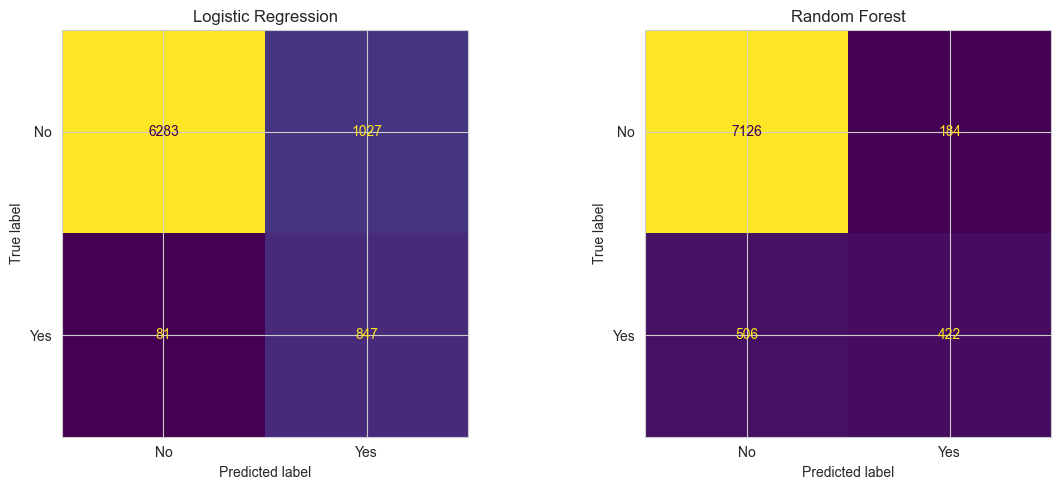

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, pred_lr), display_labels=['No', 'Yes']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay(confusion_matrix(y_test, pred_rf), display_labels=['No', 'Yes']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.show()

In [16]:
print("Logistic Regression Report:")
print(classification_report(y_test, pred_lr, target_names=['No', 'Yes']))

print("Random Forest Report:")
print(classification_report(y_test, pred_rf, target_names=['No', 'Yes']))

Logistic Regression Report:
              precision    recall  f1-score   support

          No       0.99      0.86      0.92      7310
         Yes       0.45      0.91      0.60       928

    accuracy                           0.87      8238
   macro avg       0.72      0.89      0.76      8238
weighted avg       0.93      0.87      0.88      8238

Random Forest Report:
              precision    recall  f1-score   support

          No       0.93      0.97      0.95      7310
         Yes       0.70      0.45      0.55       928

    accuracy                           0.92      8238
   macro avg       0.82      0.71      0.75      8238
weighted avg       0.91      0.92      0.91      8238



In [17]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'F1-Score': [f1_score(y_test, pred_lr), f1_score(y_test, pred_rf)],
    'ROC-AUC': [roc_auc_score(y_test, proba_lr), roc_auc_score(y_test, proba_rf)]
})
results

,Model,F1-Score,ROC-AUC
0,Logistic Regression,0.604568,0.943944
1,Random Forest,0.550196,0.950669


### ROC Curve

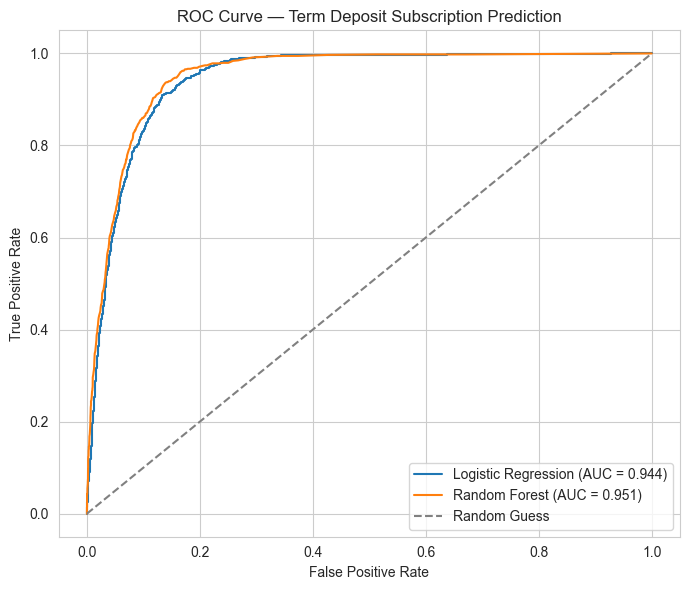

In [18]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, proba in [('Logistic Regression', proba_lr), ('Random Forest', proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Term Deposit Subscription Prediction')
ax.legend()
plt.tight_layout()
plt.show()

Both models achieve strong ROC-AUC (>0.9), meaning they rank customers by
subscription likelihood very well. Logistic Regression edges out Random
Forest on F1 here, while Random Forest gives richer, non-linear SHAP
explanations below.


## 6. Explainable AI — SHAP

We use shap.TreeExplainer on the Random Forest model to understand:
1. **Global feature importance** — which features drive predictions overall
2. **5 individual predictions** — why the model made specific decisions

In [19]:
# Train a smaller, separate Random Forest just for SHAP (much faster to explain)
rf_shap = RandomForestClassifier(
    n_estimators=100, max_depth=8, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_shap.fit(X_train, y_train)

explainer = shap.TreeExplainer(rf_shap)
X_shap_sample = X_test.sample(n=100, random_state=42)
shap_values = explainer.shap_values(X_shap_sample, check_additivity=False)

if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
else:
    shap_values_pos = shap_values[:, :, 1]

shap_values_pos.shape

(100, 47)

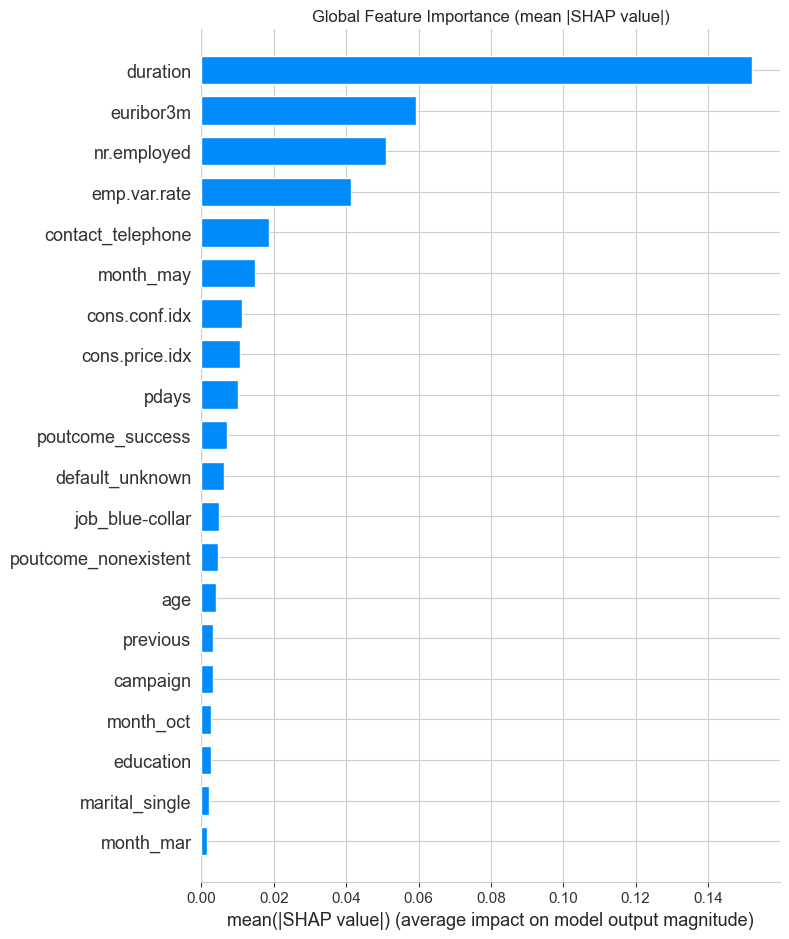

In [20]:
shap.summary_plot(shap_values_pos, X_shap_sample, plot_type='bar', show=False)
plt.title('Global Feature Importance (mean |SHAP value|)')
plt.tight_layout()
plt.show()

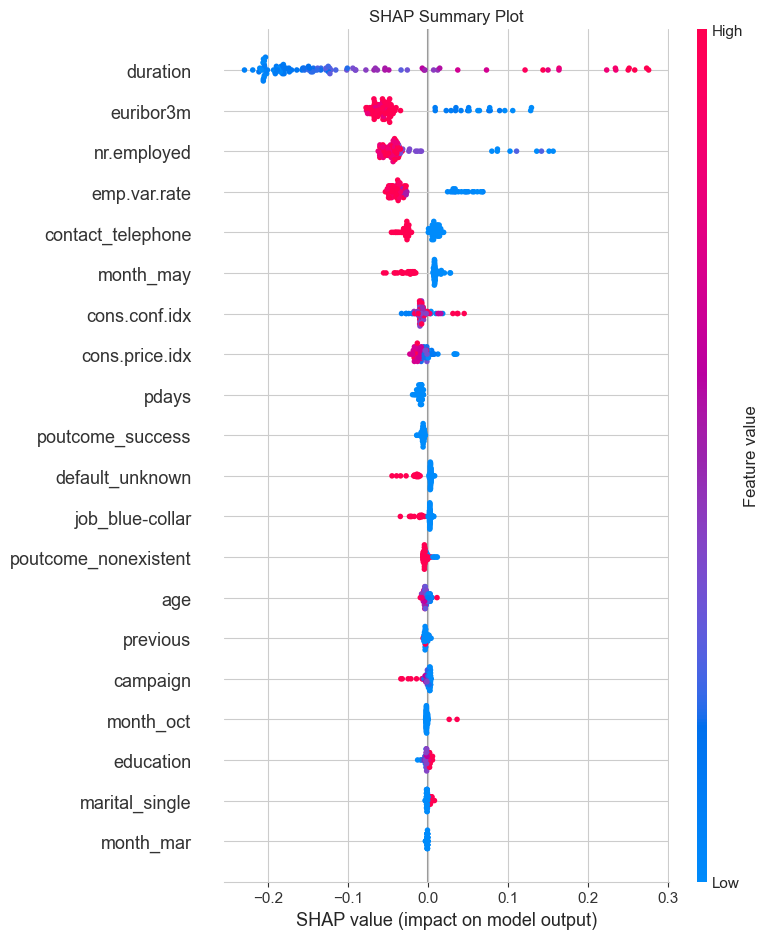

In [21]:
shap.summary_plot(shap_values_pos, X_shap_sample, show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.show()

### Explaining 5 individual predictions

We pick 5 diverse test customers: correctly predicted "yes", correctly
predicted "no", and one the model got wrong.

In [22]:
correct_yes = X_test[(pred_rf == 1) & (y_test.values == 1)].index[:2]
correct_no  = X_test[(pred_rf == 0) & (y_test.values == 0)].index[:2]
wrong_one   = X_test[(pred_rf != y_test.values)].index[:1]

sample_idx = list(correct_yes) + list(correct_no) + list(wrong_one)
sample_idx

[40138, 39198, 14455, 36380, 28008]

--- Sample 1 | Actual: Yes | Predicted: Yes ---


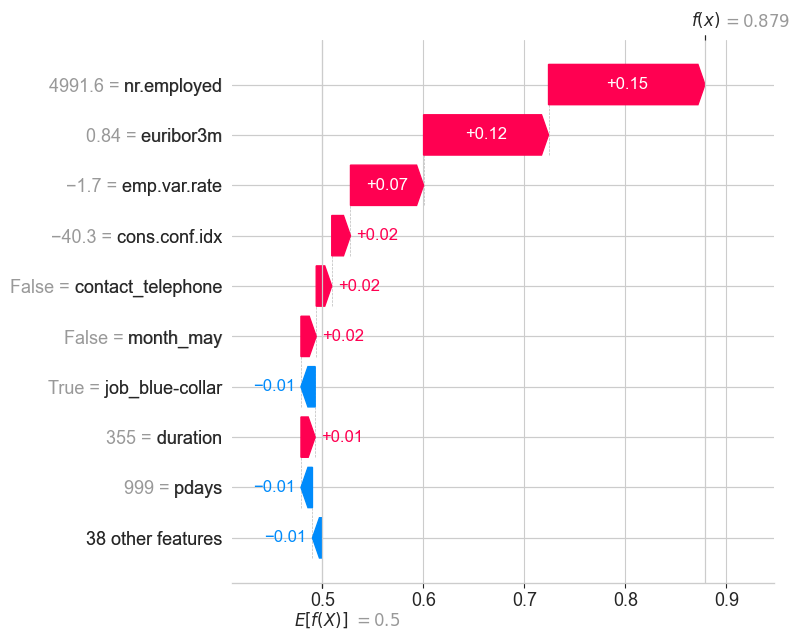

--- Sample 2 | Actual: Yes | Predicted: Yes ---


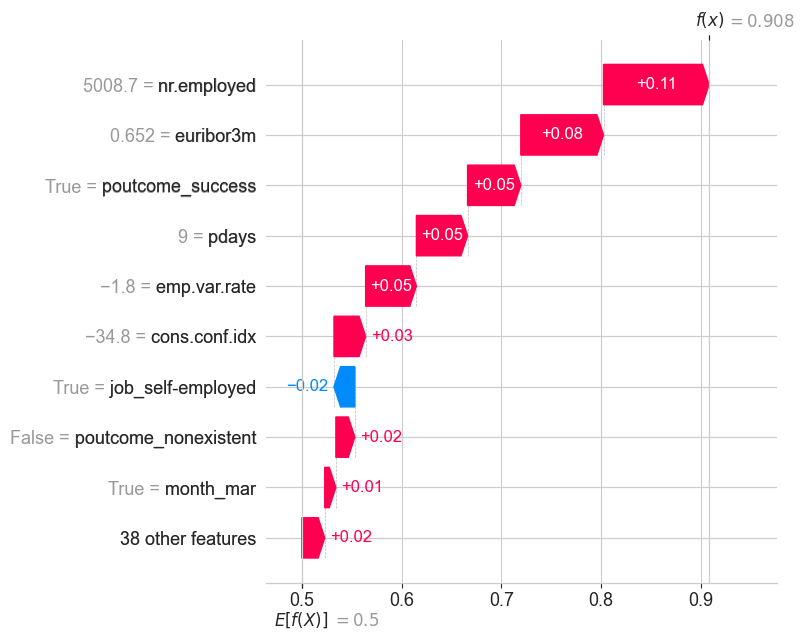

--- Sample 3 | Actual: No | Predicted: No ---


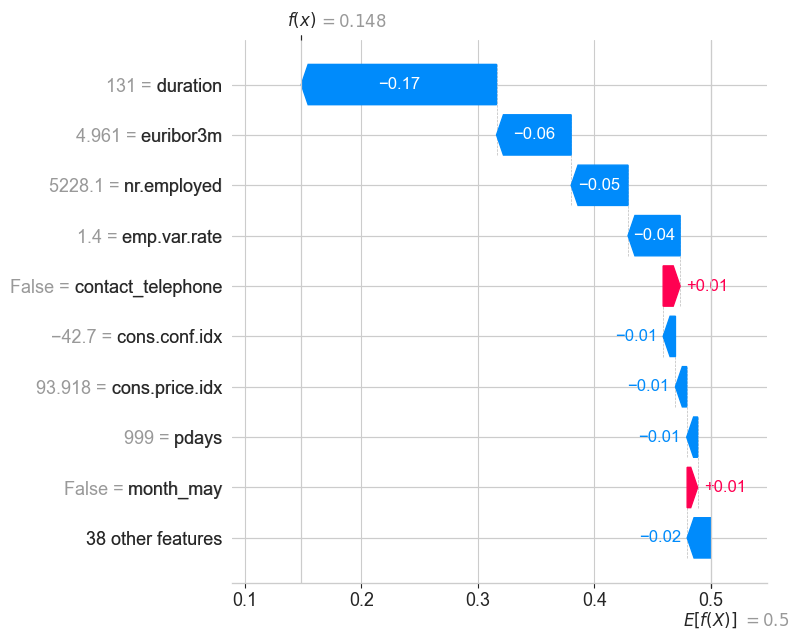

--- Sample 4 | Actual: No | Predicted: Yes ---


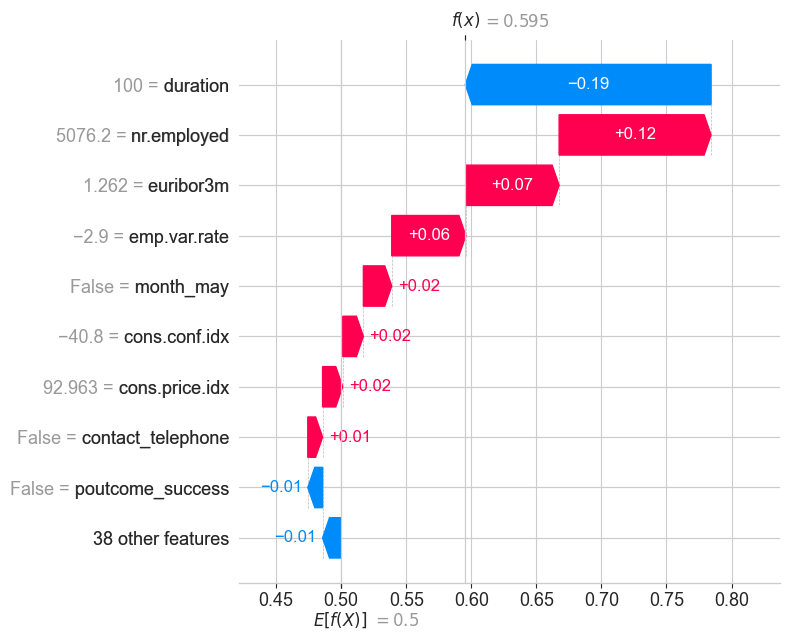

--- Sample 5 | Actual: Yes | Predicted: Yes ---


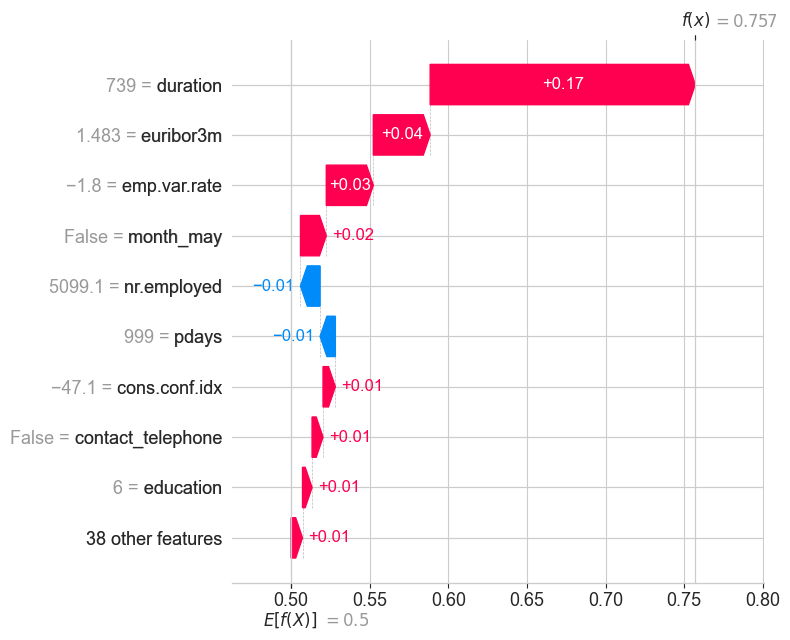

In [23]:
pred_rf_shap = rf_shap.predict(X_test)

for i, idx in enumerate(sample_idx):
    row = X_test.loc[[idx]]
    sv = explainer.shap_values(row, check_additivity=False)
    sv_pos = sv[:, :, 1][0] if not isinstance(sv, list) else sv[1][0]
    base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

    actual = 'Yes' if y_test.loc[idx] == 1 else 'No'
    predicted = 'Yes' if pred_rf_shap[X_test.index.get_loc(idx)] == 1 else 'No'
    print(f"--- Sample {i+1} | Actual: {actual} | Predicted: {predicted} ---")

    exp = shap.Explanation(values=sv_pos, base_values=base_value,
                            data=row.iloc[0].values, feature_names=row.columns.tolist())
    shap.plots.waterfall(exp, show=False)
    plt.tight_layout()
    plt.show()

Each waterfall plot shows how individual feature values push a specific
customer's prediction above or below the average subscription probability
(base value) — e.g. poutcome_success typically pushes toward "Yes", while
a short duration pushes toward "No".

## 7. Conclusion & Insights

**Model performance:** Both models achieve strong discriminative power
(ROC-AUC > 0.90 — Logistic Regression: 0.944, Random Forest: 0.951).
Logistic Regression achieved a slightly higher F1-score; Random Forest
offers richer, non-linear SHAP explanations.

**Top drivers of subscription (from SHAP):**
- Economic indicators (nr.employed, euribor3m, emp.var.rate) — strongly influence individual predictions
- poutcome_success — previously successful campaign contact is a strong positive signal
- duration — longer calls associate with subscribing (only known post-call)

**Business recommendations:**
1. Prioritize recontacting customers with a previous successful campaign outcome
2. Use the ROC curve to pick a decision threshold matching calling capacity
3. Build a secondary pre-call model excluding duration for real-time targeting
4. Time campaigns around favorable macro-economic conditions, since these clearly move individual predictions as shown by SHAP